In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Hp\Desktop\insurance-risk-analytics\data\cleaned_insurance_data.csv")

df.head()

C:\Users\Hp\AppData\Local\Temp\ipykernel_19616\3885380765.py:3: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\Hp\Desktop\insurance-risk-analytics\data\cleaned_insurance_data.csv")


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [2]:
print(df.shape)

(1000098, 52)


In [3]:
df.info()
df.head()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    1000098 non-null  str    
 12  Country                   1000098 non-null  str    
 13  Province                  1000098 non-

UnderwrittenCoverID               0
PolicyID                          0
TransactionMonth                  0
IsVATRegistered                   0
Citizenship                       0
LegalType                         0
Title                             0
Language                          0
Bank                         145961
AccountType                   40232
MaritalStatus                  8259
Gender                            0
Country                           0
Province                          0
PostalCode                        0
MainCrestaZone                    0
SubCrestaZone                     0
ItemType                          0
mmcode                          552
VehicleType                     552
RegistrationYear                  0
make                            552
Model                           552
Cylinders                       552
cubiccapacity                   552
kilowatts                       552
bodytype                        552
NumberOfDoors               

In [4]:
missing = df.isnull().sum()
missing[missing > 0]

Bank                        145961
AccountType                  40232
MaritalStatus                 8259
mmcode                         552
VehicleType                    552
make                           552
Model                          552
Cylinders                      552
cubiccapacity                  552
kilowatts                      552
bodytype                       552
NumberOfDoors                  552
VehicleIntroDate               552
CustomValueEstimate         779642
CapitalOutstanding               2
NewVehicle                  153295
WrittenOff                  641901
Rebuilt                     641901
Converted                   641901
CrossBorder                 999400
NumberOfVehiclesInFleet    1000098
dtype: int64

In [5]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [6]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\Hp\AppData\Local\Temp\ipykernel_19616\3477175695.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [7]:
df.isnull().sum().sum()

np.int64(1000098)

In [8]:
df.columns

Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='str')

In [9]:
df['VehicleAge'] = 2026 - df['RegistrationYear']

In [10]:
df[['RegistrationYear', 'VehicleAge']].head()

,RegistrationYear,VehicleAge
0,2004,22
1,2004,22
2,2004,22
3,2004,22
4,2004,22


In [11]:
drop_cols = [
    'UnderwrittenCoverID',
    'PolicyID'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [12]:
df.isnull().sum().sort_values(ascending=False)

NumberOfVehiclesInFleet     1000098
IsVATRegistered                   0
TransactionMonth                  0
LegalType                         0
Title                             0
Language                          0
Bank                              0
AccountType                       0
MaritalStatus                     0
Gender                            0
Country                           0
Province                          0
PostalCode                        0
MainCrestaZone                    0
SubCrestaZone                     0
ItemType                          0
mmcode                            0
VehicleType                       0
Citizenship                       0
RegistrationYear                  0
make                              0
Cylinders                         0
Model                             0
kilowatts                         0
bodytype                          0
NumberOfDoors                     0
cubiccapacity                     0
CustomValueEstimate         

In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [14]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\Hp\AppData\Local\Temp\ipykernel_19616\3477175695.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [15]:
df = pd.get_dummies(df, drop_first=True)

In [16]:
severity_df = df[df['TotalClaims'] > 0]

In [17]:
severity_df.shape

(2788, 1874)

In [18]:
X = severity_df.drop('TotalClaims', axis=1)

y = severity_df['TotalClaims']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
X.isnull().sum().sort_values(ascending=False)

NumberOfVehiclesInFleet                   2788
Product_Standalone Passenger Liability       0
CoverGroup_Credit Protection                 0
CoverGroup_Deposit Cover                     0
CoverGroup_Fire,Theft and Third Party        0
                                          ... 
CoverType_Windscreen                         0
CoverGroup_Asset Value Preserver             0
CoverGroup_Baggage/Luggage                   0
CoverGroup_Basic Excess Waiver               0
IsVATRegistered                              0
Length: 1873, dtype: int64

In [21]:
X.isnull().sum().sum()

np.int64(2788)

In [22]:
# Numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

# Categorical columns
cat_cols = X.select_dtypes(include=['object']).columns

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

In [23]:
X = pd.get_dummies(X, drop_first=True)

In [24]:
X = X.fillna(0)

In [25]:
X.isnull().sum().sum()

np.int64(0)

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

r2_lr = r2_score(y_test, pred_lr)

print("RMSE:", rmse_lr)
print("R2:", r2_lr)

RMSE: 37588.825704134935
R2: 0.12145401250320997


In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

r2_rf = r2_score(y_test, pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 36141.56439143473
Random Forest R2: 0.18780394228509678


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
X.dtypes

IsVATRegistered                                               bool
PostalCode                                                   int64
mmcode                                                     float64
RegistrationYear                                             int64
Cylinders                                                  float64
                                                            ...   
Section_Standalone passenger liability                        bool
Section_Third party or third party, fire and theft only       bool
Product_Mobility Commercial Cover: Monthly                    bool
Product_Mobility Metered Taxis: Monthly                       bool
Product_Standalone Passenger Liability                        bool
Length: 1873, dtype: object

In [31]:
X = pd.get_dummies(X, drop_first=True)

In [32]:
X = X.astype(float)

In [33]:
X = X.loc[:, ~X.columns.duplicated()]

In [34]:
X = X.fillna(0)

In [35]:
X.dtypes.unique()

array([dtype('float64')], dtype=object)

In [36]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

r2_xgb = r2_score(y_test, pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R2:", r2_xgb)

AttributeError: 'DataFrame' object has no attribute 'dtype'

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R2': [r2_lr, r2_rf, r2_xgb]
})

comparison

,Model,RMSE,R2
0,Linear Regression,37588.825704,0.121454
1,Random Forest,36141.564391,0.187804
2,XGBoost,37378.113596,0.131276


In [ ]:
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

In [ ]:
X_cls = df.drop(['HasClaim', 'TotalClaims'], axis=1)

y_cls = df['HasClaim']

In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = RandomForestClassifier(random_state=42)

clf.fit(X_train_c, y_train_c)

pred_cls = clf.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, pred_cls))
print("Precision:", precision_score(y_test_c, pred_cls))
print("Recall:", recall_score(y_test_c, pred_cls))
print("F1:", f1_score(y_test_c, pred_cls))

MemoryError: Unable to allocate 5.58 GiB for an array with shape (1873, 800078) and data type float32

In [ ]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Hp\Desktop\insurance-risk-analytics\data\cleaned_insurance_data.csv"
)

C:\Users\Hp\AppData\Local\Temp\ipykernel_12568\3216306185.py:3: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [ ]:
drop_cols = [
    'UnderwrittenCoverID',
    'PolicyID',
    'PostalCode',
    'mmcode',
    'Model',
    'SubCrestaZone',
    'MainCrestaZone',
    'VehicleIntroDate'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\Hp\AppData\Local\Temp\ipykernel_12568\3477175695.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [ ]:
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

MemoryError: Unable to allocate 964. MiB for an array with shape (1000098, 1011) and data type bool

In [37]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    r"C:\Users\Hp\Desktop\insurance-risk-analytics\data\cleaned_insurance_data.csv"
)

C:\Users\Hp\AppData\Local\Temp\ipykernel_19616\3027859182.py:4: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [38]:
df = df.sample(n=100000, random_state=42)

In [39]:
selected_cols = [
    'IsVATRegistered',
    'Citizenship',
    'LegalType',
    'MaritalStatus',
    'Gender',
    'Province',
    'VehicleType',
    'make',
    'bodytype',
    'RegistrationYear',
    'Cylinders',
    'cubiccapacity',
    'kilowatts',
    'NumberOfDoors',
    'CustomValueEstimate',
    'SumInsured',
    'CalculatedPremiumPerTerm',
    'TotalPremium',
    'TotalClaims'
]

df = df[selected_cols]

In [40]:
df['VehicleAge'] = 2026 - df['RegistrationYear']

In [41]:
df = df.drop(columns=['RegistrationYear'])

In [42]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [43]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\Hp\AppData\Local\Temp\ipykernel_19616\3477175695.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [44]:
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

In [45]:
df = pd.get_dummies(
    df,
    columns=[
        'Citizenship',
        'LegalType',
        'MaritalStatus',
        'Gender',
        'Province',
        'VehicleType',
        'make',
        'bodytype'
    ],
    drop_first=True
)

In [46]:
df = df.astype('float32')

In [47]:
df.shape

(100000, 93)

In [48]:
severity_df = df[df['TotalClaims'] > 0]

In [49]:
X = severity_df.drop('TotalClaims', axis=1)

y = severity_df['TotalClaims']

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

r2_lr = r2_score(y_test, pred_lr)

print(rmse_lr, r2_lr)

22507.030723753855 0.1430187225341797


In [52]:
df.sample(n=100000)

,IsVATRegistered,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims,...,bodytype_CCL,bodytype_D/C,bodytype_D/S,bodytype_H/B,bodytype_MPV,bodytype_P/V,bodytype_S/C,bodytype_S/D,bodytype_S/W,bodytype_SUV
662620,0.0,4.0,2237.0,75.0,4.0,220000.0,7500.0,2.939200,2.578246,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
120485,0.0,4.0,2148.0,65.0,4.0,250000.0,7000.0,85.000000,74.561401,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
872800,0.0,4.0,2694.0,111.0,4.0,220000.0,7500.0,90.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
433291,0.0,4.0,2148.0,110.0,5.0,220000.0,600000.0,1076.019165,943.876465,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
123243,0.0,4.0,2237.0,76.0,4.0,220000.0,5000000.0,1.347100,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856463,0.0,4.0,2694.0,111.0,4.0,220000.0,5000000.0,2.413800,2.117368,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
924059,0.0,4.0,2694.0,111.0,4.0,220000.0,7500.0,6.155700,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
875978,0.0,4.0,2694.0,111.0,4.0,138000.0,100000.0,50.000000,43.859650,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
952707,0.0,4.0,2237.0,76.0,4.0,220000.0,7500.0,2.939200,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

r2_xgb = r2_score(y_test, pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R2:", r2_xgb)

XGBoost RMSE: 19100.746791683305
XGBoost R2: 0.38278621435165405


In [59]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

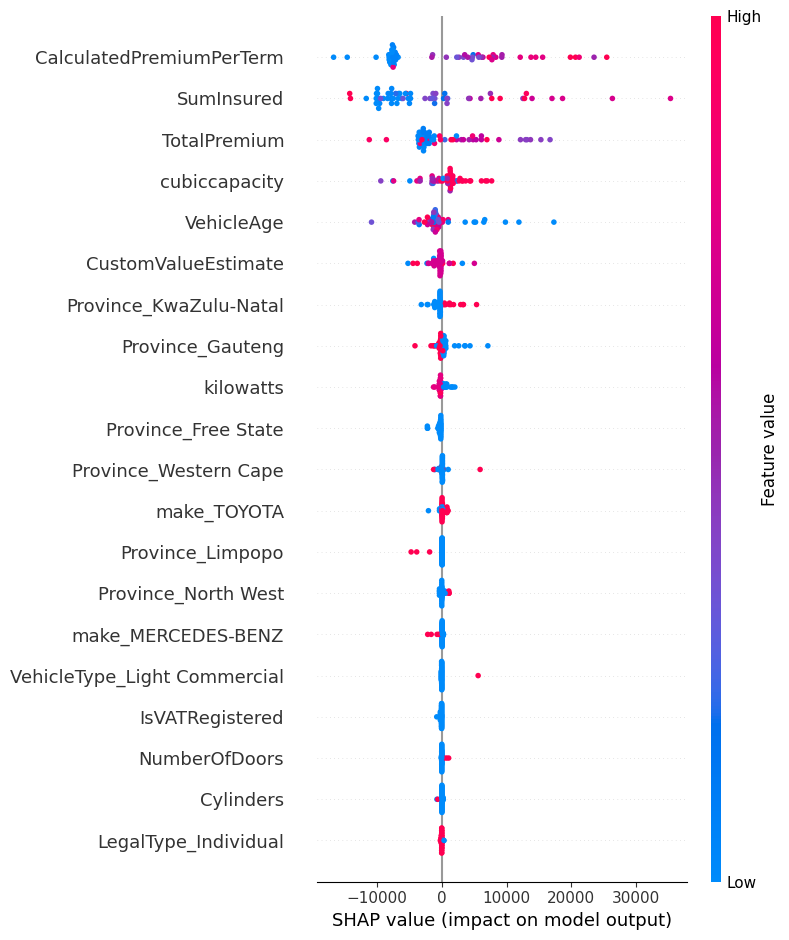

In [60]:
shap.summary_plot(shap_values, X_test)

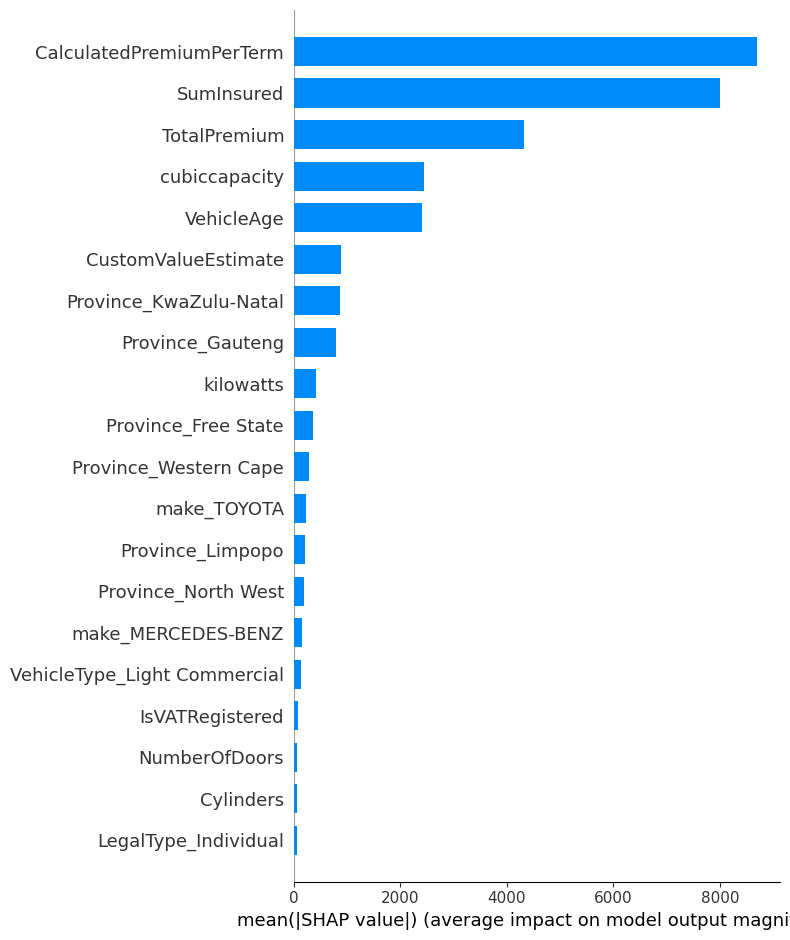

In [61]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [62]:
pred_xgb = xgb.predict(X_test[:5])

print(pred_xgb)

[ 1379.1465 27848.562   1498.0862 52356.824   1326.8369]


In [63]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R2': [r2_lr, r2_rf, r2_xgb]
})

comparison

,Model,RMSE,R2
0,Linear Regression,22507.030724,0.143019
1,Random Forest,36141.564391,0.187804
2,XGBoost,19100.746792,0.382786


## Business Interpretation

SHAP analysis shows that SumInsured is the most influential
feature affecting claim severity predictions.

Higher insured amounts are associated with larger expected claims,
which supports risk-based premium adjustments.

VehicleAge also contributes significantly to prediction.
Older vehicles tend to generate larger repair costs and therefore
higher claim severity.

CalculatedPremiumPerTerm strongly impacts predictions,
suggesting that current pricing already reflects underlying risk factors.

Province and VehicleType influence the model as well,
indicating geographic and vehicle-category differences in insurance risk.